In [ ]:
import pandas as pd
import zipfile
import os
import io
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

In [3]:
zip_file_path = "C:/Users/ben.pharris/Downloads/reerecompetitiveresearchtelcoadvertisermediaspe.zip"

In [4]:
import pandas as pd
import os
import re # Using re for robust pattern matching

# --- 1. Setup the path to your folder ---
# The 'r' before the string is important to handle the backslashes correctly in Windows paths.
folder_path = r'C:\Users\ben.pharris\Downloads\reerecompetitiveresearchtelcoadvertisermediaspe'

# --- 2. Create an empty list to hold the data from each file ---
all_data_rows = []

print(f"Starting to process files in: {folder_path}")

# --- 3. Loop through every file in the specified directory ---
for filename in os.listdir(folder_path):
    # Process only if the file is an Excel file
    if filename.endswith('.xlsx'):
        full_path = os.path.join(folder_path, filename)
        print(f"  -> Reading file: {filename}")

        # --- 4. Read header from row 18 and data from row 19 ---
        # skiprows=17 tells pandas to skip the first 17 rows.
        # Reading will start at row 18, which is used as the header.
        # nrows=1 tells pandas to read only one row of data (row 19).
        # usecols="A:F" specifies the exact columns to read.
        try:
            row_df = pd.read_excel(
                full_path,
                skiprows=17,
                nrows=1,
                usecols="A:F"
            )

            # --- 5. Determine the quarter from the filename ---
            quarter_value = None
            if re.search('Q1', filename, re.IGNORECASE):
                quarter_value = 1
            elif re.search('Q2', filename, re.IGNORECASE):
                quarter_value = 2
            
            # Add the new 'quarter' column to our single-row DataFrame
            row_df['quarter'] = quarter_value

            # --- 6. Add the processed row to our list ---
            all_data_rows.append(row_df)

        except Exception as e:
            print(f"      !! Could not process file {filename}. Error: {e}")


# --- 7. Combine all the individual rows into one final DataFrame ---
if all_data_rows:
    # The column names will be automatically taken from row 18 of the files.
    final_df = pd.concat(all_data_rows, ignore_index=True)

    print("\n--- Processing Complete! ---")
    print("Final DataFrame Head:")
    print(final_df.head())
    print("\nFinal DataFrame Info:")
    final_df.info()
else:
    print("\nNo Excel files were found or processed.")



Starting to process files in: C:\Users\ben.pharris\Downloads\reerecompetitiveresearchtelcoadvertisermediaspe
  -> Reading file: AT&T Inc. - Spend by Product Line Q1'25.xlsx
  -> Reading file: AT&T Inc. - Spend by Product Line Q2'25.xlsx
  -> Reading file: DISH Wireless  - Spend by Product Line Q1'25.xlsx
  -> Reading file: DISH Wireless  - Spend by Product Line Q2'25.xlsx
  -> Reading file: T-Mobile - Spend by Product Line Q1'25.xlsx
  -> Reading file: T-Mobile - Spend by Product Line Q2'25.xlsx
  -> Reading file: Verizon Communications, Inc - Spend by Product Line Q1'25.xlsx
  -> Reading file: Verizon Communications, Inc - Spend by Product Line Q2'25.xlsx

--- Processing Complete! ---
Final DataFrame Head:
                                  Product Line   TV Spend  Digital Spend  \
0       AT&T Inc. (Including Subsidiary Spend)  191026241       71107616   
1       AT&T Inc. (Including Subsidiary Spend)  127074203       65836580   
2  DISH Wireless  (Including Subsidiary Spend)    45282

--- Data prepared for plotting ---
quarter               1          2
Company                           
AT&T          263102763  193685873
Boost Mobile   39703297   24217200
T-Mobile      310325775  250936047
Verizon       374893223  224336219


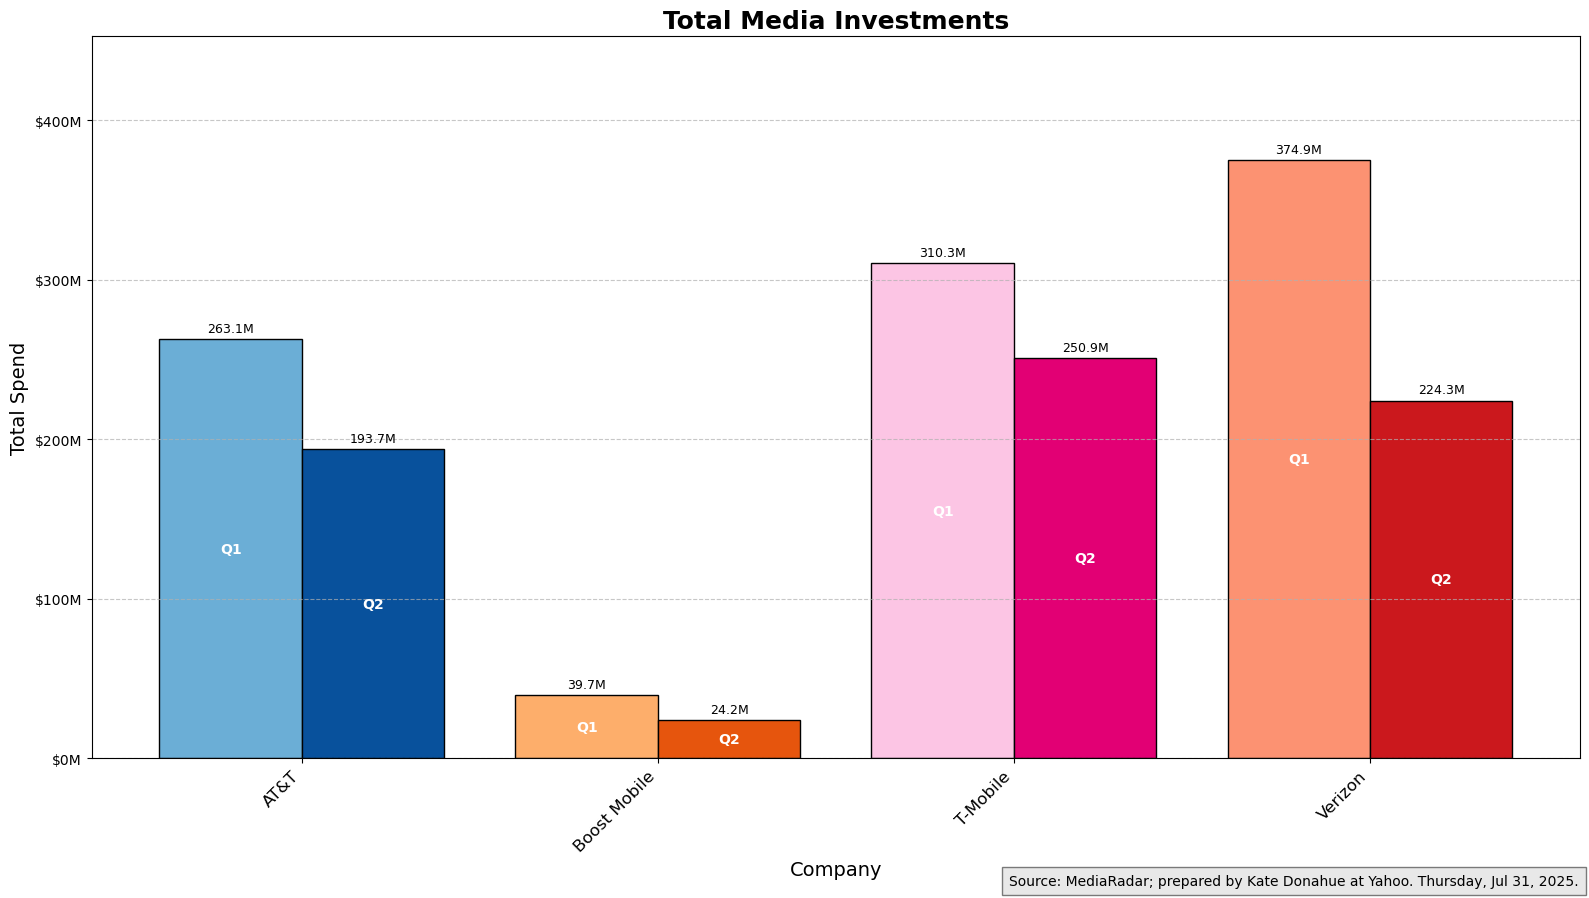

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

# --- Assume 'final_df' exists from the previous cell ---
# If not, you would load your data here, e.g., final_df = pd.read_csv('your_data.csv')

# --- 1. Data Preparation ---

# Make a copy to avoid changing the original DataFrame
plot_df = final_df.copy()

# --- Define the exact column names we need to use ---
# IMPORTANT: If your column names are slightly different (e.g., "Product_Line"),
# update these variables to match the names in your DataFrame.
product_line_col_name = 'Product Line'
total_spend_col_name = 'Total Spend'

# --- Check if the required columns exist ---
if product_line_col_name not in plot_df.columns or total_spend_col_name not in plot_df.columns:
    print("!!! ERROR: Required columns not found.")
    print(f"    Looking for '{product_line_col_name}' and '{total_spend_col_name}'.")
    print(f"    Available columns are: {list(plot_df.columns)}")
else:
    # Define a function to extract the company name based on your rules
    def get_company_name(product_line):
        if pd.isna(product_line):
            return "Unknown"
        # Get the first word
        first_word = str(product_line).split(' ')[0]
        # Apply the special rule for "Dish"
        if first_word.lower() == 'dish':
            return 'Boost Mobile'
        return first_word

    # Create the new 'Company' column by applying the function
    plot_df['Company'] = plot_df[product_line_col_name].apply(get_company_name)

    # Clean and ensure the spend column is a numeric type for calculation
    # Remove '$' and ',' characters, then convert to a number. Coerce errors to NaN.
    plot_df[total_spend_col_name] = plot_df[total_spend_col_name].astype(str).str.replace(r'[$,]', '', regex=True)
    plot_df[total_spend_col_name] = pd.to_numeric(plot_df[total_spend_col_name], errors='coerce')


    # --- 2. Group and Aggregate Data ---

    # Group by 'Company' and 'quarter', calculate the sum of the ABSOLUTE spend
    # .unstack() pivots the 'quarter' values into separate columns (e.g., 1 and 2)
    # .fillna(0) ensures that if a company has no spend in a quarter, it's treated as 0 for plotting
    spend_by_company = plot_df.groupby(['Company', 'quarter'])[total_spend_col_name].apply(lambda x: x.abs().sum()).unstack().fillna(0)

    print("--- Data prepared for plotting ---")
    print(spend_by_company)


    # --- 3. Generate the Bar Plot with Enhanced Formatting ---
    if not spend_by_company.empty:
        # Define the color map: [Q1_color, Q2_color]
        color_map = {
            'AT&T': ['#6baed6', '#08519c'],         # light/dark blue
            'Boost Mobile': ['#fdae6b', '#e6550d'], # light/dark orange
            'T-Mobile': ['#fcc5e4', '#e20074'],     # light pink / T-Mobile magenta
            'Verizon': ['#fc9272', '#cb181d'],      # light/dark red
            'Default': ['#bdbdbd', '#636363']      # light/dark grey for any others
        }
        
        # Setup for plotting
        companies = spend_by_company.index
        quarters = spend_by_company.columns
        n_companies = len(companies)
        n_quarters = len(quarters)
        
        x = np.arange(n_companies)  # the label locations
        bar_width = 0.8 / n_quarters  # the width of the bars, adjusted for number of quarters
        
        fig, ax = plt.subplots(figsize=(16, 9))

        # Loop through each quarter to plot its bars with custom colors
        for i, quarter in enumerate(quarters):
            # Calculate position for this set of bars
            offset = bar_width * (i - (n_quarters - 1) / 2)
            
            # Get values and colors for this quarter's bars
            values = spend_by_company[quarter]
            # Look up the color for each company for the current quarter (i)
            bar_colors = [color_map.get(company, color_map['Default'])[i] for company in companies]
            
            rects = ax.bar(x + offset, values, bar_width, color=bar_colors, edgecolor='black')

            # Add value labels on top of each bar
            ax.bar_label(rects, padding=3, fmt=lambda v: f'{v/1_000_000:.1f}M' if v > 0 else '', fontsize=9)
            
            # Add Q1/Q2 labels INSIDE each bar
            ax.bar_label(rects, labels=[f'Q{int(quarter)}' for _ in rects], label_type='center', color='white', fontweight='bold', fontsize=10)

        # --- Format Y-axis to show millions ---
        def millions_formatter(val, pos):
            return f'${val/1_000_000:.0f}M'
        ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))

        # Set titles and labels
        ax.set_title('Total Media Investments', fontsize=18, fontweight='bold')
        ax.set_ylabel('Total Spend', fontsize=14)
        ax.set_xlabel('Company', fontsize=14)
        
        # Set x-ticks and labels
        ax.set_xticks(x)
        ax.set_xticklabels(companies, rotation=45, ha='right', fontsize=12)
        
        # The legend is no longer needed
        # ax.legend(title='Quarter', fontsize=12) 
        
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        # Adjust Y-axis limit to make space for labels
        ax.set_ylim(top=ax.get_ylim()[1] * 1.15)

        fig.tight_layout()
        
        # --- Add the source text to the bottom right of the figure ---
        plt.figtext(0.99, 0.01, "Source: MediaRadar; prepared by Kate Donahue at Yahoo. Thursday, Jul 31, 2025.", ha="right", fontsize=10, bbox={"facecolor":"lightgray", "alpha":0.5, "pad":5})

        plt.show()
    else:
        print("\n--- Plotting skipped: No data to plot after grouping. Check your 'Company' and 'quarter' columns. ---")


In [6]:
import snowflake.snowpark as snowpark
import snowflake.snowpark.functions as F
from snowflake.snowpark.types import StringType, StructType, StructField, TimestampType
import pandas as pd
import numpy as np
from datetime import date
from datetime import datetime
import re
from snowflake.snowpark import Session
from snowflake.snowpark.functions import sum, col, coalesce
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from datetime import timedelta
from thefuzz import fuzz

In [7]:
connection_parameters = {
    "account": "yva20138.us-west-2.privatelink",
    "user": "ben.pharris@dish.com",
    "authenticator": "externalbrowser",
    "insecure_mode":True,
}


session = Session.builder.configs(connection_parameters).create()

source_table = "DISH_RETAIL_DL.MARS.DE0008_OPENSIGNAL_WMS_METRICS"
date_col = "DATE"

sql_query = f"""
    SELECT *
    FROM {source_table}
    WHERE LEFT({date_col}, 4) > '2023'
"""
sp = session.sql(sql_query)
snowdf = sp.to_pandas()
snowdf['DATE'] = pd.to_datetime(snowdf['DATE'])
snowdf['MONTHLY_VALUE'] = pd.to_numeric(
    snowdf['MONTHLY_VALUE'],
    errors='coerce'
)

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://dish.okta.com/app/snowflake/exk9ewak82R5btDoW2p7/sso/saml?SAMLRequest=pZJbc9owEIX%2Fikd9tiWLkIAGk6EwaZlJUy5OMumbsAUoliVHK2P495W5dNKH5CVvGumsvrN7dnC7L1WwExak0QmKI4ICoTOTS71J0GN6F%2FZQAI7rnCujRYIOAtDtcAC8VBUb1W6rF%2BKtFuAC%2F5EG1j4kqLaaGQ4SmOalAOYythz9umc0IowDCOs8Dp1LcpCetXWuYhg3TRM1ncjYDaaEEEz62KtayTf0DlF9zqiscSYz6lKy9z19gIgxuWoRXuEJs3Phd6lPI%2FiMsjqJgP1M01k4%2B71MUTC6dDc2GupS2KWwO5mJx8X9yQB4By9PI0riTi%2BqIWz87EIaVVbuuBNK6iICbZq14oXITFnVziMif8JrkWNlNtIPbjpJUFXIfK136Xz8Oj8UdNUvd%2Fn0MF90yWv6bNO5%2BzG%2Bbq61mqze6gU3GQqeLjHTNuYpQC2mug3X%2BStCuyHphaSbxles02ExiegN%2FYOCiTcoNXfHyksHuYRtZArHj854VeF%2FprHYF33R8KJHF92Vm5hnWt1gAIPb4NBpd9iRbodfmsgAv%2F%2FqvJMPPqbpZGaUzA7BnbEldx%2BnGEfx8Ubm4fooZaLkUo3y3AoAn6ZSphlb4X0kyNlaIDw8Uf9f%2FuFf&RelayState

In [27]:
opensignal_df = snowdf.copy()

--- Generating stacked bar plot for: Gross Adds ---

--- Quarterly values for: Gross Adds ---
         CARRIER  Postpaid_Q1  Prepaid_Q1  Postpaid_Q2  Prepaid_Q2
            AT&T    2,129,000     320,987    2,144,550     282,619
        T-Mobile    2,475,003     482,288    2,712,859     526,865
Verizon Wireless    2,369,000     319,858    2,507,707     301,278
    Boost Mobile       44,828     607,006       41,647     672,777




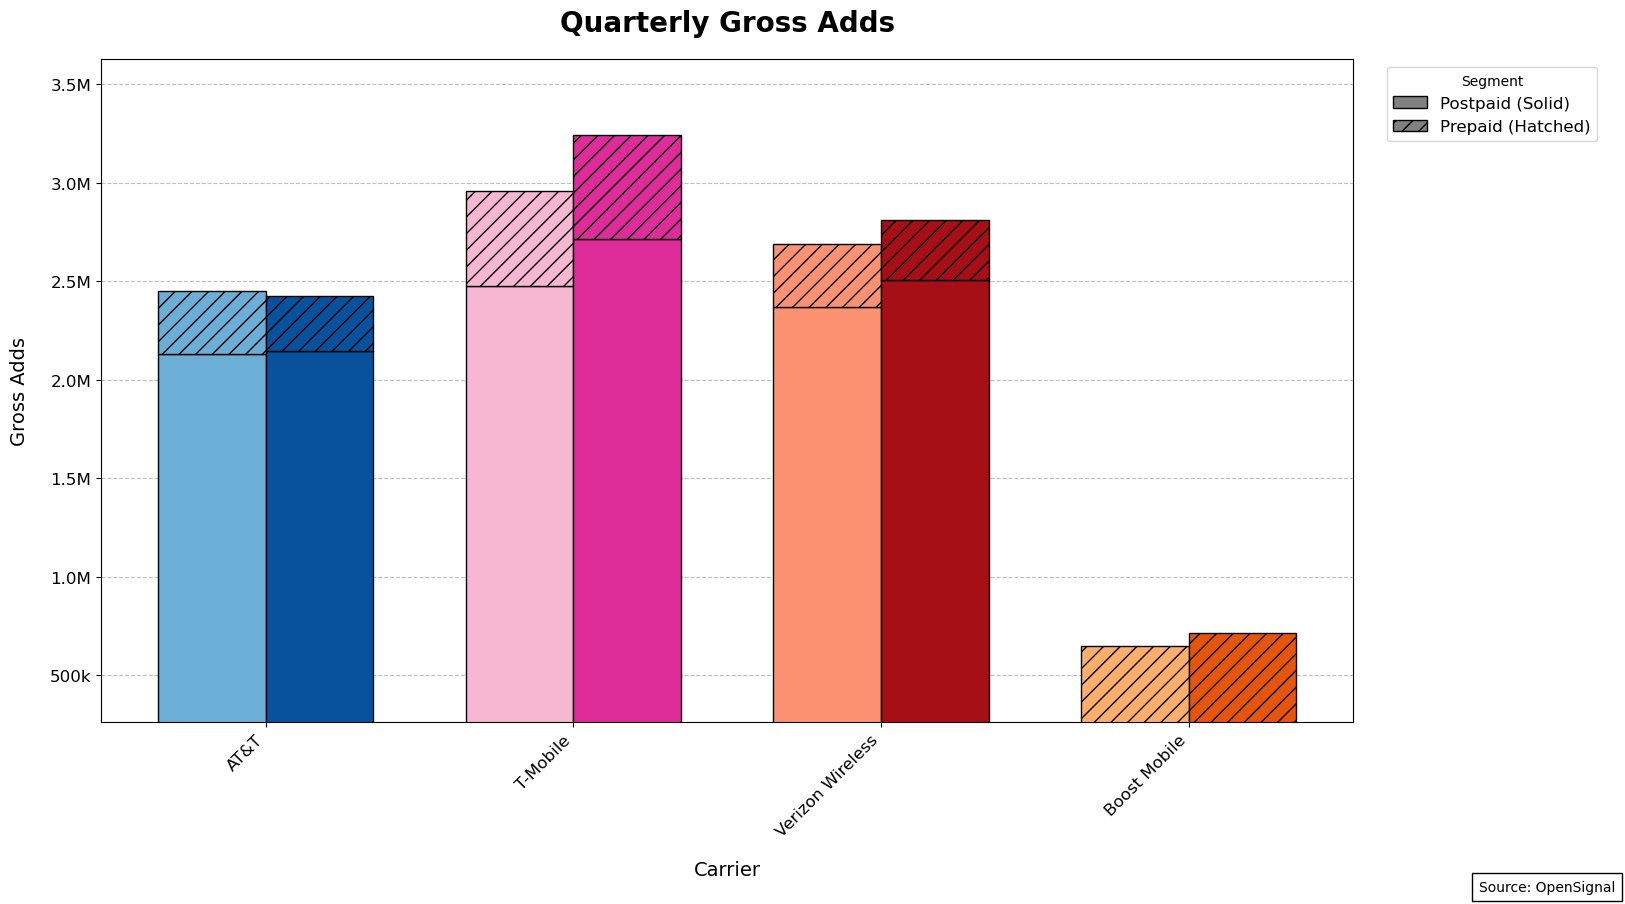

--- Generating stacked bar plot for: Net Adds ---

--- Quarterly values for: Net Adds ---
         CARRIER  Postpaid_Q1  Prepaid_Q1  Postpaid_Q2  Prepaid_Q2
            AT&T      324,000     -27,940      323,945     -33,899
        T-Mobile      384,169      33,715      757,514      62,289
Verizon Wireless     -289,000      16,159       -7,588     -17,400
    Boost Mobile       45,470     137,001       39,208      46,160




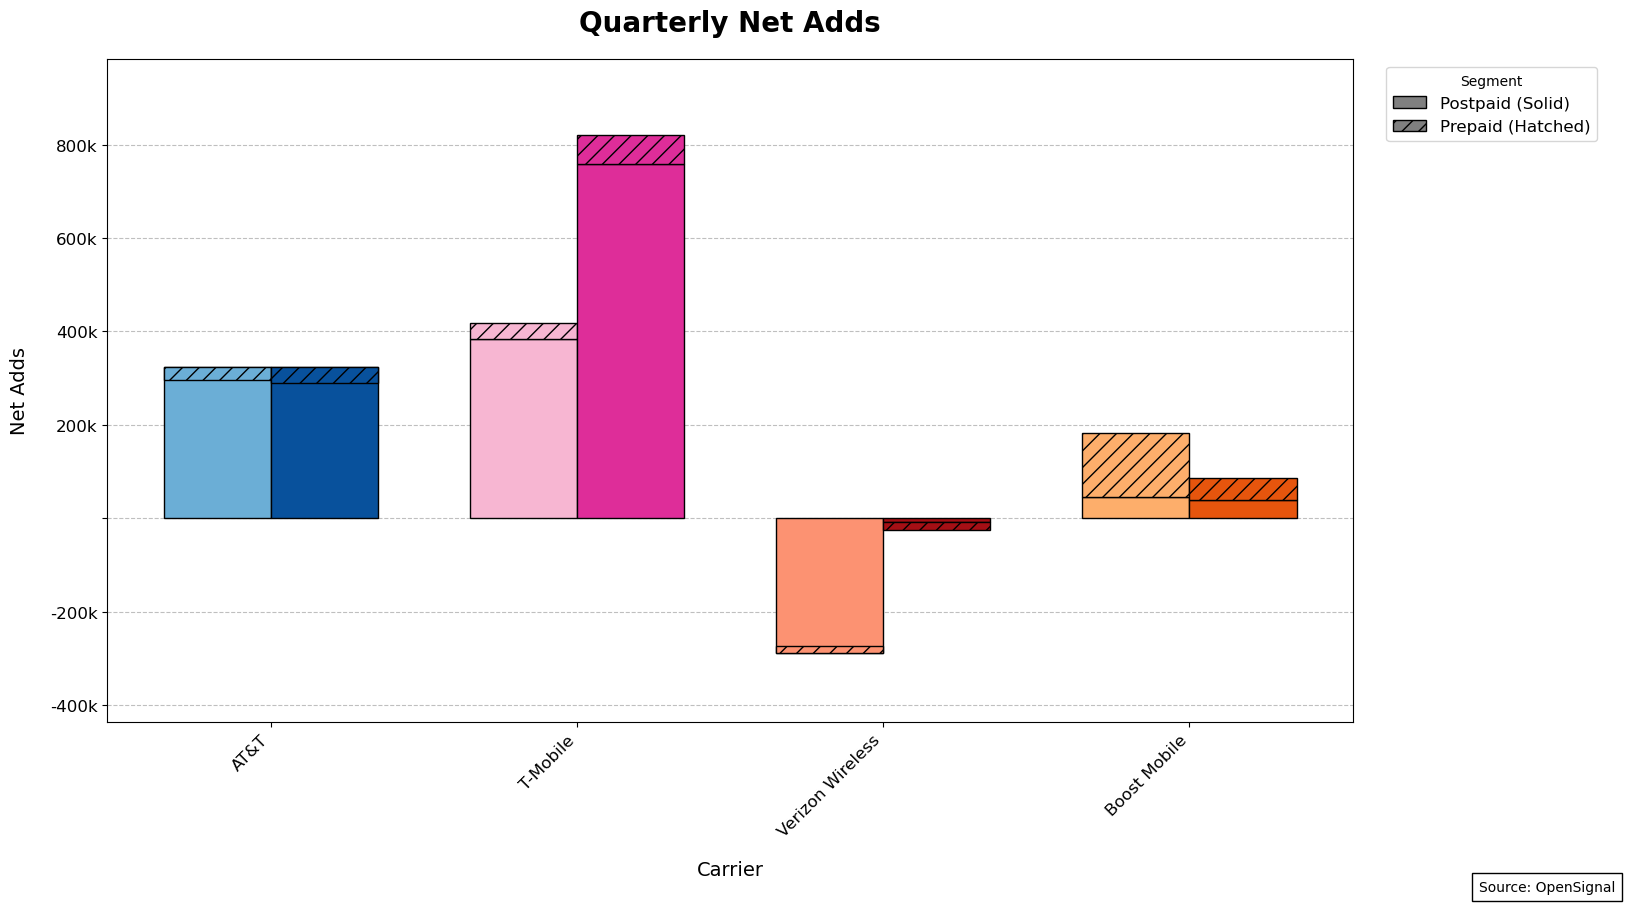

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch # Needed for the custom legend

# --- 1. Data Loading ---
# This script assumes 'opensignal_df' is a pandas DataFrame that has already been loaded.

# --- Set display format for cleaner printing of large numbers ---
pd.set_option('display.float_format', '{:,.0f}'.format)

# --- 2. Data Preparation and Filtering ---
opensignal_df['DATE'] = pd.to_datetime(opensignal_df['DATE'])
carriers_to_plot = ['AT&T', 'T-Mobile', 'Verizon Wireless', 'Boost Mobile']
segments_to_plot = ['Postpaid', 'Prepaid']
metrics_to_plot = ['Gross Adds', 'Net Adds']

df_filtered = opensignal_df[
    (opensignal_df['DATE'] >= '2025-01-01') &
    (opensignal_df['DATE'] <= '2025-06-30') &
    (opensignal_df['GEO_DMA'] == 'National') &
    (opensignal_df['CARRIER'].isin(carriers_to_plot)) &
    (opensignal_df['SEGMENT'].isin(segments_to_plot)) &
    (opensignal_df['METRIC'].isin(metrics_to_plot))
].copy()

# --- 3. Loop Through Metrics to Generate Plots ---

for metric in metrics_to_plot:
    print(f"--- Generating stacked bar plot for: {metric} ---")
    metric_df = df_filtered[df_filtered['METRIC'] == metric]

    q1_start, q1_end = '2025-01-01', '2025-03-31'
    q2_start, q2_end = '2025-04-01', '2025-06-30'

    def get_quarterly_summary(df, start_date, end_date):
        quarter_df = df[(df['DATE'] >= start_date) & (df['DATE'] <= end_date)]
        summary = quarter_df.groupby(['CARRIER', 'SEGMENT'])['MONTHLY_VALUE'].sum()
        return summary.unstack(level='SEGMENT').fillna(0)

    q1_summary = get_quarterly_summary(metric_df, q1_start, q1_end)
    q2_summary = get_quarterly_summary(metric_df, q2_start, q2_end)

    summary_df = pd.merge(
        q1_summary, q2_summary, on='CARRIER', how='outer', suffixes=('_Q1', '_Q2')
    ).fillna(0)

    for segment in segments_to_plot:
        for quarter in ['Q1', 'Q2']:
            col_name = f'{segment}_{quarter}'
            if col_name not in summary_df.columns:
                summary_df[col_name] = 0
    
    summary_df = summary_df.reindex(carriers_to_plot).reset_index()

    # --- MANUAL DATA APPEND FOR BOOST MOBILE POSTPAID ---
    boost_mobile_index = summary_df[summary_df['CARRIER'] == 'Boost Mobile'].index
    if not boost_mobile_index.empty:
        if metric == 'Gross Adds':
            summary_df.loc[boost_mobile_index, 'Postpaid_Q1'] = 44828
            summary_df.loc[boost_mobile_index, 'Postpaid_Q2'] = 41647
        elif metric == 'Net Adds':
            summary_df.loc[boost_mobile_index, 'Postpaid_Q1'] = 45470
            summary_df.loc[boost_mobile_index, 'Postpaid_Q2'] = 39208

    print(f"\n--- Quarterly values for: {metric} ---")
    print(summary_df.to_string(index=False))
    print("\n")

    if summary_df.empty:
        print(f"No data found for metric '{metric}'. Skipping plot.")
        continue

    # --- Visualization ---
    colors_q1 = {'AT&T': '#6BAED6', 'Boost Mobile': '#FDAE6B', 'T-Mobile': '#F7B6D2', 'Verizon Wireless': '#FC9272'}
    colors_q2 = {'AT&T': '#08519C', 'Boost Mobile': '#E6550D', 'T-Mobile': '#DE2D99', 'Verizon Wireless': '#A50F15'}

    q1_color_list = summary_df['CARRIER'].map(colors_q1).fillna('grey').tolist()
    q2_color_list = summary_df['CARRIER'].map(colors_q2).fillna('grey').tolist()

    fig, ax = plt.subplots(figsize=(18, 10))
    carriers = summary_df['CARRIER']
    ind = np.arange(len(carriers))
    width = 0.35
    hatch_pattern = '//'

    # Plotting Q1 & Q2 Bars
    ax.bar(ind - width/2, summary_df['Postpaid_Q1'], width, color=q1_color_list, edgecolor='black')
    ax.bar(ind - width/2, summary_df['Prepaid_Q1'], width, bottom=summary_df['Postpaid_Q1'], color=q1_color_list, edgecolor='black', hatch=hatch_pattern)
    ax.bar(ind + width/2, summary_df['Postpaid_Q2'], width, color=q2_color_list, edgecolor='black')
    ax.bar(ind + width/2, summary_df['Prepaid_Q2'], width, bottom=summary_df['Postpaid_Q2'], color=q2_color_list, edgecolor='black', hatch=hatch_pattern)

    # --- Formatting and Labels ---
    ax.set_title(f"Quarterly {metric}", fontsize=20, fontweight='bold', pad=20)
    ax.set_ylabel(f"{metric}", fontsize=14, labelpad=15)
    ax.set_xlabel('Carrier', fontsize=14, labelpad=15)
    ax.set_xticks(ind)
    ax.set_xticklabels(carriers, rotation=45, ha='right', fontsize=12)
    ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.5)
    ax.set_axisbelow(True)

    def format_M_or_k(value, tick_number=None):
        if value == 0:
            return ''
        elif abs(value) >= 1_000_000:
            return f'{value/1_000_000:.1f}M'
        else:
            return f'{value/1_000:.0f}k'

    ax.yaxis.set_major_formatter(FuncFormatter(format_M_or_k))
    ax.tick_params(axis='y', labelsize=12)
    
    # --- ALL AUTOMATIC BAR AND QUARTER LABELS HAVE BEEN REMOVED ---
    
    # --- Simplified Legend ---
    legend_handles = [
        Patch(facecolor='grey', edgecolor='black', label='Postpaid (Solid)'),
        Patch(facecolor='grey', edgecolor='black', label='Prepaid (Hatched)', hatch=hatch_pattern)
    ]
    ax.legend(handles=legend_handles, title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)

    q1_totals = summary_df['Postpaid_Q1'] + summary_df['Prepaid_Q1']
    q2_totals = summary_df['Postpaid_Q2'] + summary_df['Prepaid_Q2']
    all_totals = pd.concat([q1_totals, q2_totals])
    if not all_totals.empty:
        min_val, max_val = all_totals.min(), all_totals.max()
        y_buffer = (max_val - min_val) * 0.15 if (max_val - min_val) > 0 else abs(max_val) * 0.25
        ax.set_ylim(bottom=min_val - y_buffer, top=max_val + y_buffer)

    fig.text(0.9, 0.05, 'Source: OpenSignal', ha='right', va='bottom', fontsize=10,
             bbox=dict(boxstyle='square,pad=0.5', fc='white', ec='black'))
    
    plt.tight_layout(rect=[0, 0.05, 0.9, 0.95])
    plt.show()

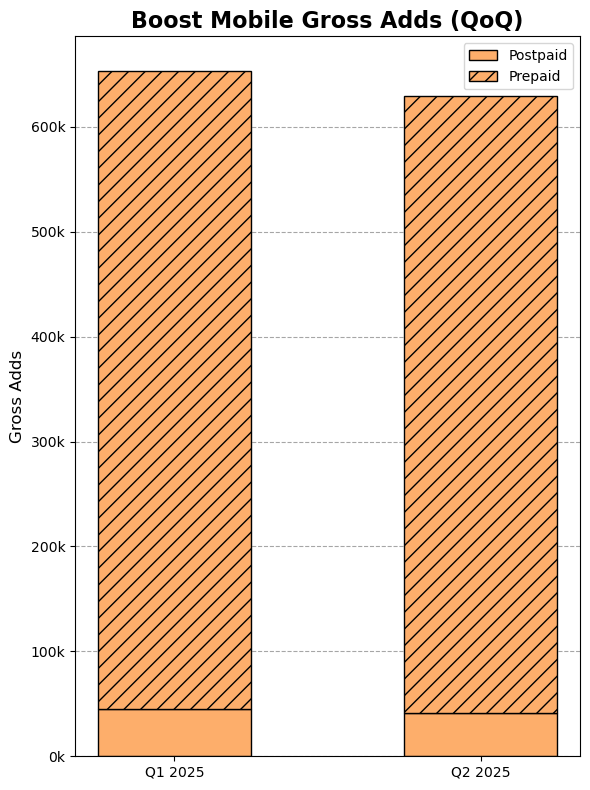

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --- Data for Boost Mobile Gross Adds ---
labels = ['Q1 2025', 'Q2 2025']
prepaid_adds = [608737, 588091]
postpaid_adds = [44828, 41647]

# --- Colors and Hatching ---
# Using the same color scheme for consistency
color = '#FDAE6B' # Light Orange for Boost Mobile
hatch_pattern = '//'

# --- Plotting ---
fig, ax = plt.subplots(figsize=(6, 8))
width = 0.5

# Create the stacked bars
postpaid_bars = ax.bar(labels, postpaid_adds, width, label='Postpaid', color=color, edgecolor='black')
prepaid_bars = ax.bar(labels, prepaid_adds, width, bottom=postpaid_adds, label='Prepaid', color=color, edgecolor='black', hatch=hatch_pattern)

# --- Formatting and Labels ---
ax.set_title('Boost Mobile Gross Adds (QoQ)', fontsize=16, fontweight='bold')
ax.set_ylabel('Gross Adds', fontsize=12)
ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)
ax.set_axisbelow(True)

# Format Y-axis to show thousands (k)
def format_k(value, tick_number):
    return f'{value/1000:.0f}k'
ax.yaxis.set_major_formatter(FuncFormatter(format_k))


# Add a simple legend
ax.legend()

plt.tight_layout()
plt.show()